<a href="https://colab.research.google.com/github/aakilkhanemon/Computational-Drug-Discovery-Project/blob/main/System_Pharmacology_and_Network_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

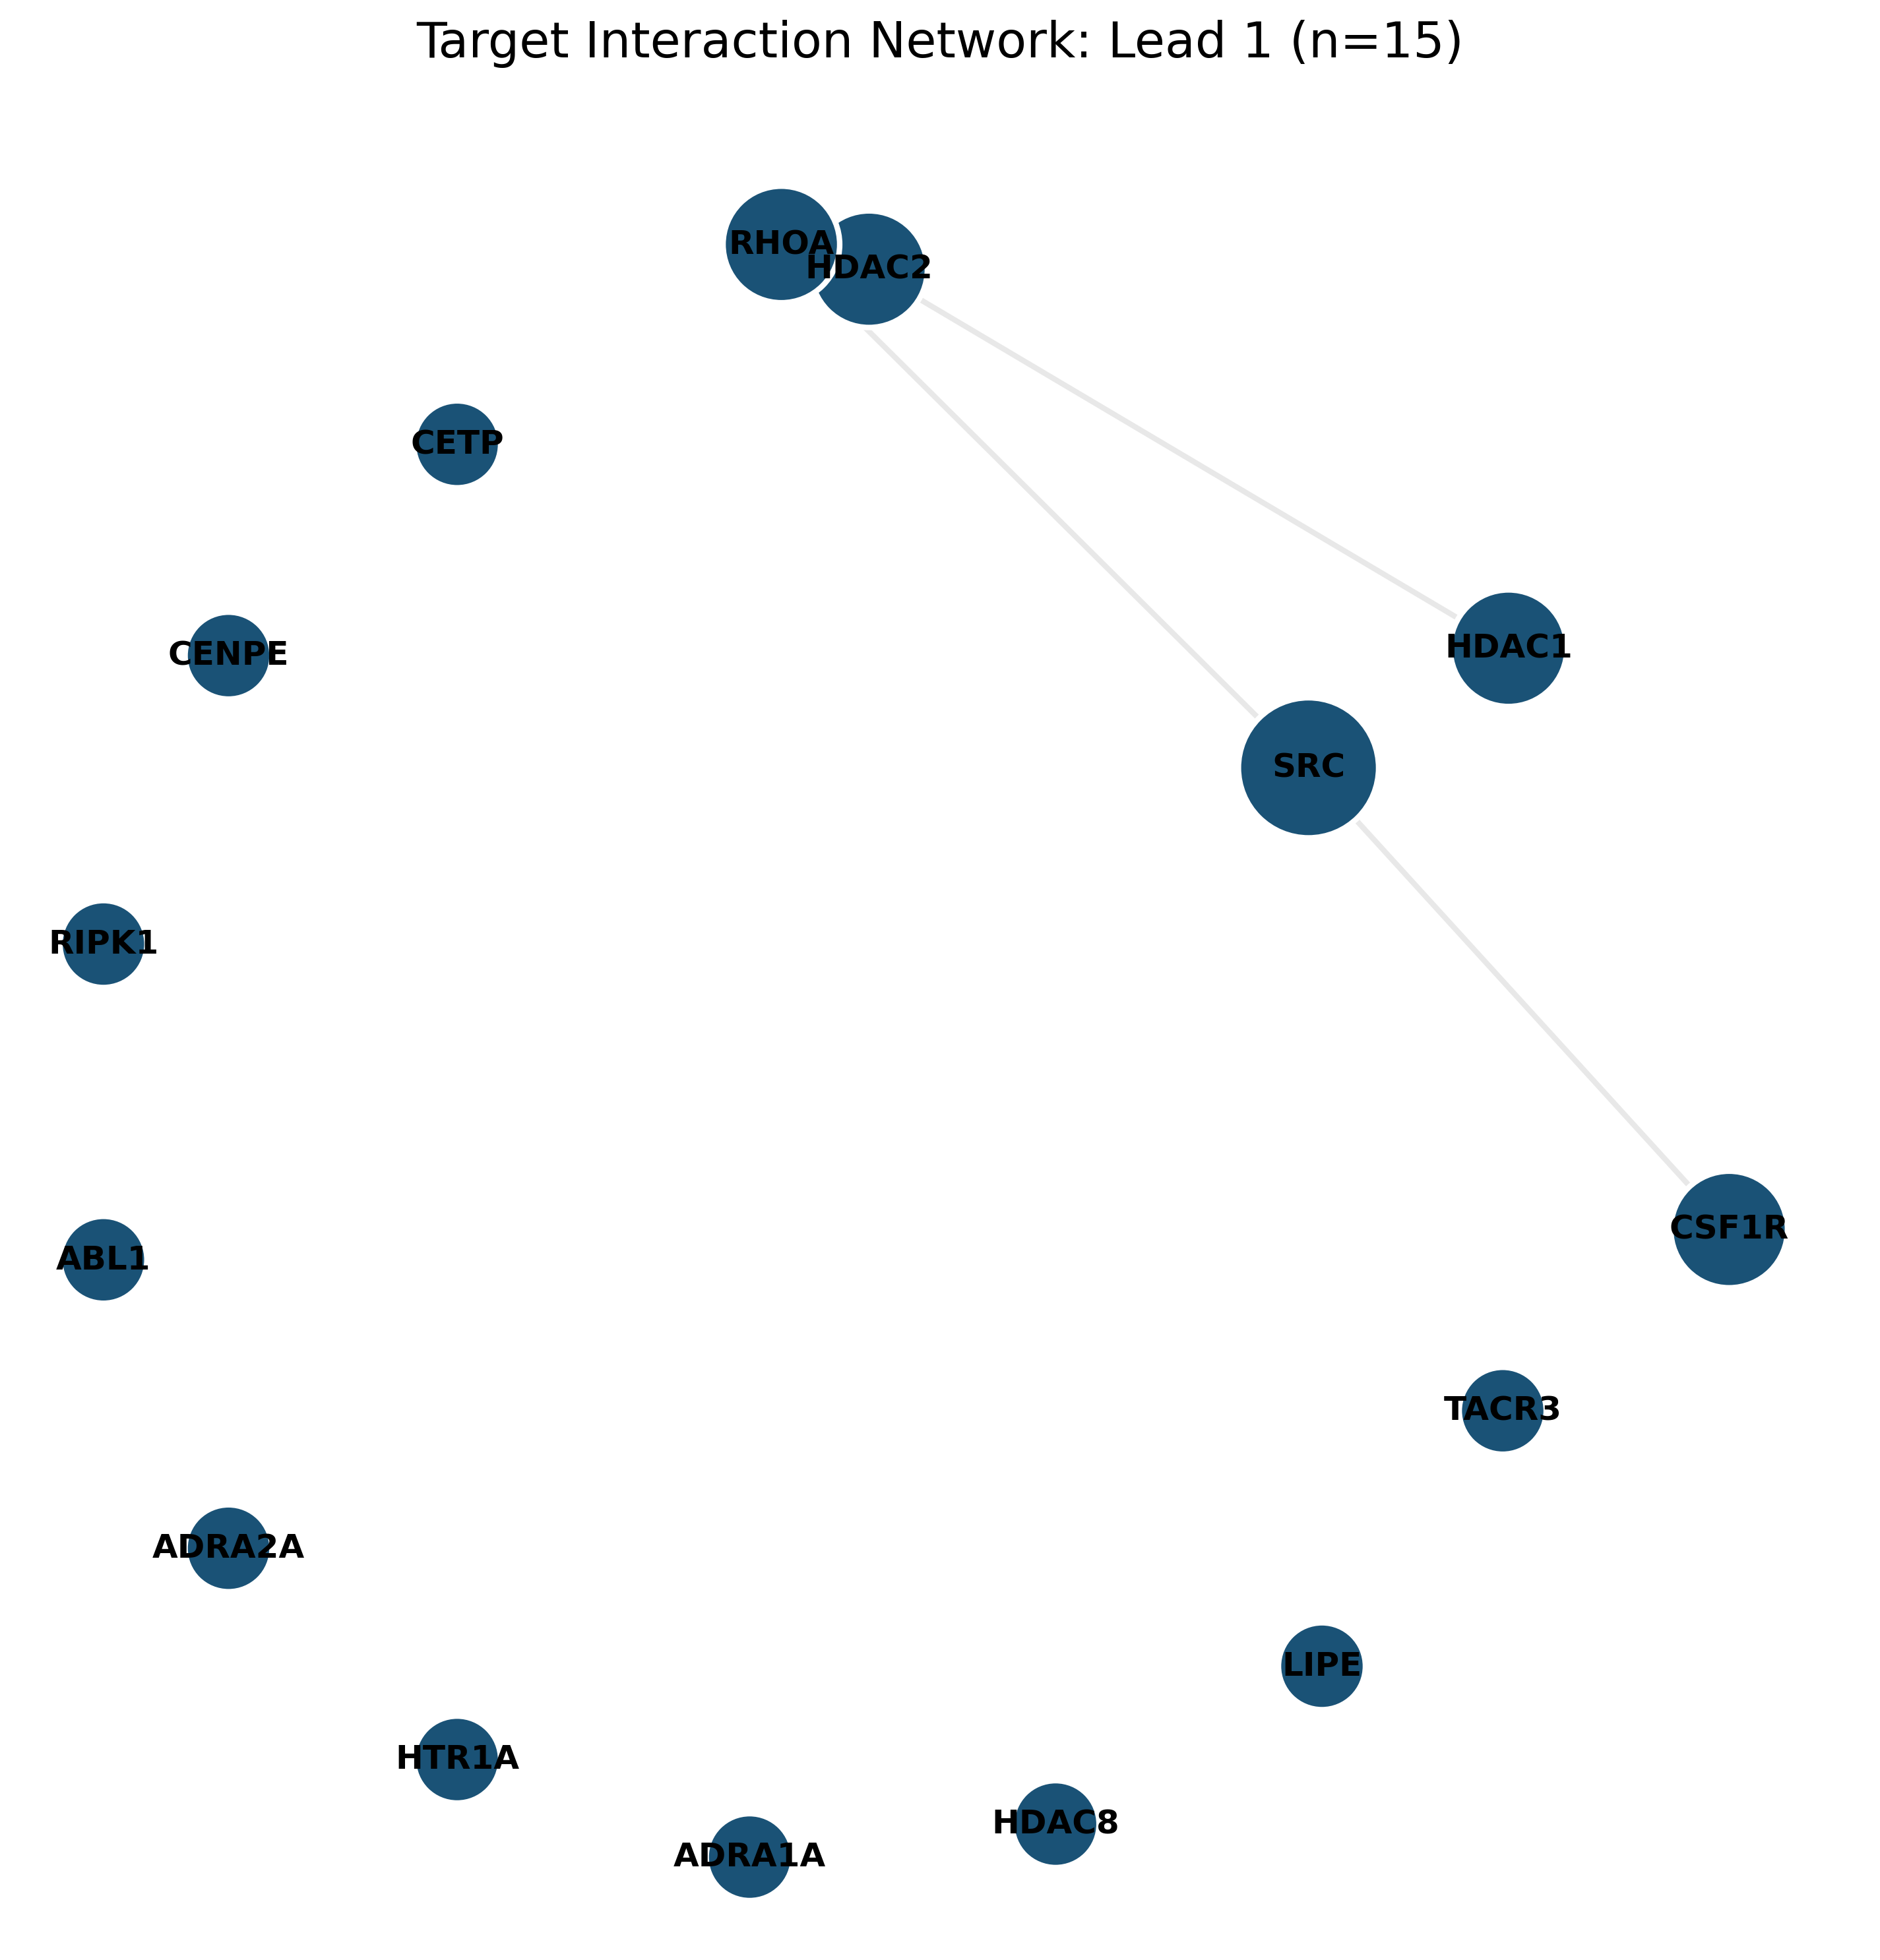

High-resolution figure (600 DPI) generated as 'Lead_1_Network_HighRes.png'


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import requests

# 1. Lead 1 Target List
lead_1_targets = ["RHOA", "CETP", "CENPE", "RIPK1", "ABL1", "ADRA2A",
                  "HTR1A", "ADRA1A", "SRC", "HDAC2", "HDAC8",
                  "HDAC1", "CSF1R", "LIPE", "TACR3"]

# 2. Fetching STRING Data (High Confidence Threshold 0.700)
string_url = "https://string-db.org/api/json/network"
params = {
    "identifiers": "\r".join(lead_1_targets),
    "species": 9606,
    "required_score": 700, # This ensures "Classical" high-stringency
    "caller_identity": "mpox_lead1_supp"
}
res = requests.post(string_url, data=params).json()

# 3. Graph Construction
G = nx.Graph()
for edge in res:
    G.add_edge(edge['preferredName_A'], edge['preferredName_B'], weight=edge['score'])
G.add_nodes_from(lead_1_targets) # Include isolates

# 4. Topological Scaling (Cytoscape Style)
degree = dict(G.degree())
# Nodes are sized by their Degree (Hubness)
node_sizes = [v * 800 + 1000 for v in degree.values()]

# 5. Visual Rendering (Super High Res)
plt.figure(figsize=(12, 12), dpi=300) # 300 DPI is the Journal Standard
pos = nx.kamada_kawai_layout(G) # Most professional layout for PPI

# Draw Edges (Thicker = Stronger Interaction)
nx.draw_networkx_edges(G, pos, width=2, edge_color='#D3D3D3', alpha=0.5)

# Draw Nodes (Monochromatic Lead 1 Navy)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#1a5276',
                       edgecolors='white', linewidths=2)

# Draw Labels
nx.draw_networkx_labels(G, pos, font_size=12, font_family='sans-serif',
                        font_weight='bold', font_color='black')

plt.title(f"Target Interaction Network: Lead 1 (n=15)", fontsize=18, pad=20)
plt.axis('off')

# 6. Saving the Publication-Ready File
plt.savefig("Lead_1_Network_HighRes.png", format='png', bbox_inches='tight', dpi=600)
plt.show()

print("High-resolution figure (600 DPI) generated as 'Lead_1_Network_HighRes.png'")

In [ ]:
import requests
from IPython.display import Image, display

# 1. Lead 1 Target List
lead_1_targets = ["RHOA", "CETP", "CENPE", "RIPK1", "ABL1", "ADRA2A",
                  "HTR1A", "ADRA1A", "SRC", "HDAC2", "HDAC8",
                  "HDAC1", "CSF1R", "LIPE", "TACR3"]

# 2. STRING API Image Endpoint
# We use 'high_res_image' for publication quality
string_api_url = "https://string-db.org/api/high_res_image/network"

# 3. Parameters to match the "Classical" look exactly:
params = {
    "identifiers": "\r".join(lead_1_targets),
    "species": 9606,            # Homo sapiens
    "add_nodes": 0,             # Don't add random proteins
    "network_flavor": "evidence", # Shows the colorful 'noodle' edges
    "required_score": 700,      # High confidence (0.700)
    "block_structure_pics": 0,  # 0 means SHOW the 3D protein structures inside bubbles
    "caller_identity": "mpox_lead1_rsc"
}

# 4. Request the image
response = requests.post(string_api_url, data=params)

# 5. Save and Display
if response.status_code == 200:
    with open("Lead1_Classical_STRING.png", 'wb') as f:
        f.write(response.content)
    print("Classical STRING Figure Generated Successfully.")
    display(Image("Lead1_Classical_STRING.png"))
else:
    print(f"Error: {response.status_code}")

Error: 404


In [ ]:
import requests
from IPython.display import Image, display

# Corrected list for Lead 1
lead_targets = ["RHOA", "CETP", "CENPE", "RIPK1", "ABL1", "ADRA2A",
                "HTR1A", "ADRA1A", "SRC", "HDAC2", "HDAC8",
                "HDAC1", "CSF1R", "LIPE", "TACR3"]

# CRITICAL: Use the high_res_image endpoint for publication quality
url = "https://string-db.org/api/high_res_image/network"

params = {
    "identifiers": "\r".join(lead_targets),
    "species": 9606,           # Taxonomy ID for Human
    "required_score": 700,     # High confidence threshold
    "network_flavor": "evidence", # Colorful edges as seen in your reference
    "block_structure_pics": 0, # Shows 3D protein structures in bubbles
    "caller_identity": "mpox_research_v1"
}

response = requests.post(url, data=params)

if response.status_code == 200:
    with open("Lead1_Classical.png", "wb") as f:
        f.write(response.content)
    display(Image("Lead1_Classical.png"))
else:
    print(f"Error {response.status_code}: Check your URL or Protein IDs")

Error 404: Check your URL or Protein IDs


Success! High-resolution SVG generated.


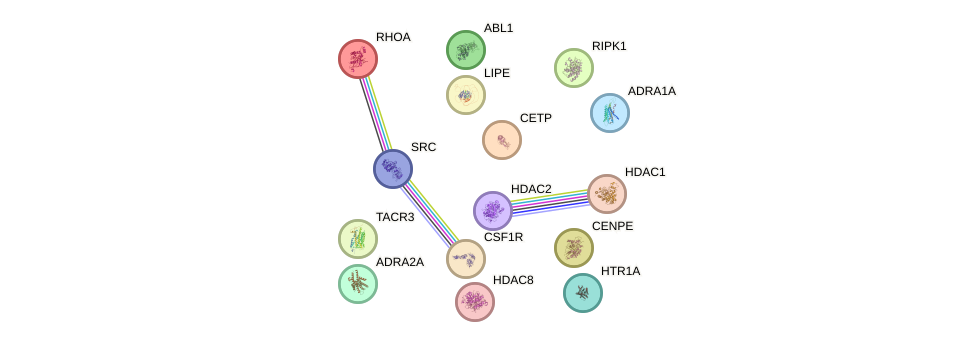

In [ ]:
import requests
from IPython.display import SVG, display

# 1. Lead 1 Target List - Explicitly cleaned
lead_1_targets = ["RHOA", "CETP", "CENPE", "RIPK1", "ABL1", "ADRA2A",
                  "HTR1A", "ADRA1A", "SRC", "HDAC2", "HDAC8",
                  "HDAC1", "CSF1R", "LIPE", "TACR3"]

# 2. Use the SVG endpoint (Better for High-Res zoom and avoids 404 on some image renders)
# If this fails, change 'svg' to 'png'
string_api_url = "https://version12.string-db.org/api/svg/network"

# 3. Parameters
params = {
    "identifiers": "\r".join([p.strip() for p in lead_1_targets]),
    "species": 9606,
    "required_score": 700,
    "network_flavor": "evidence",
    "block_structure_pics": 0,
    "caller_identity": "mpox_lead1_rsc"
}

# 4. Request
response = requests.post(string_api_url, data=params)

# 5. Output
if response.status_code == 200:
    with open("Lead1_Classical.svg", "wb") as f:
        f.write(response.content)
    print("Success! High-resolution SVG generated.")
    display(SVG(response.content))
else:
    print(f"Status Code: {response.status_code}")
    print("If 404 persists, the STRING server might be temporarily rejecting 'Evidence' requests for this list.")

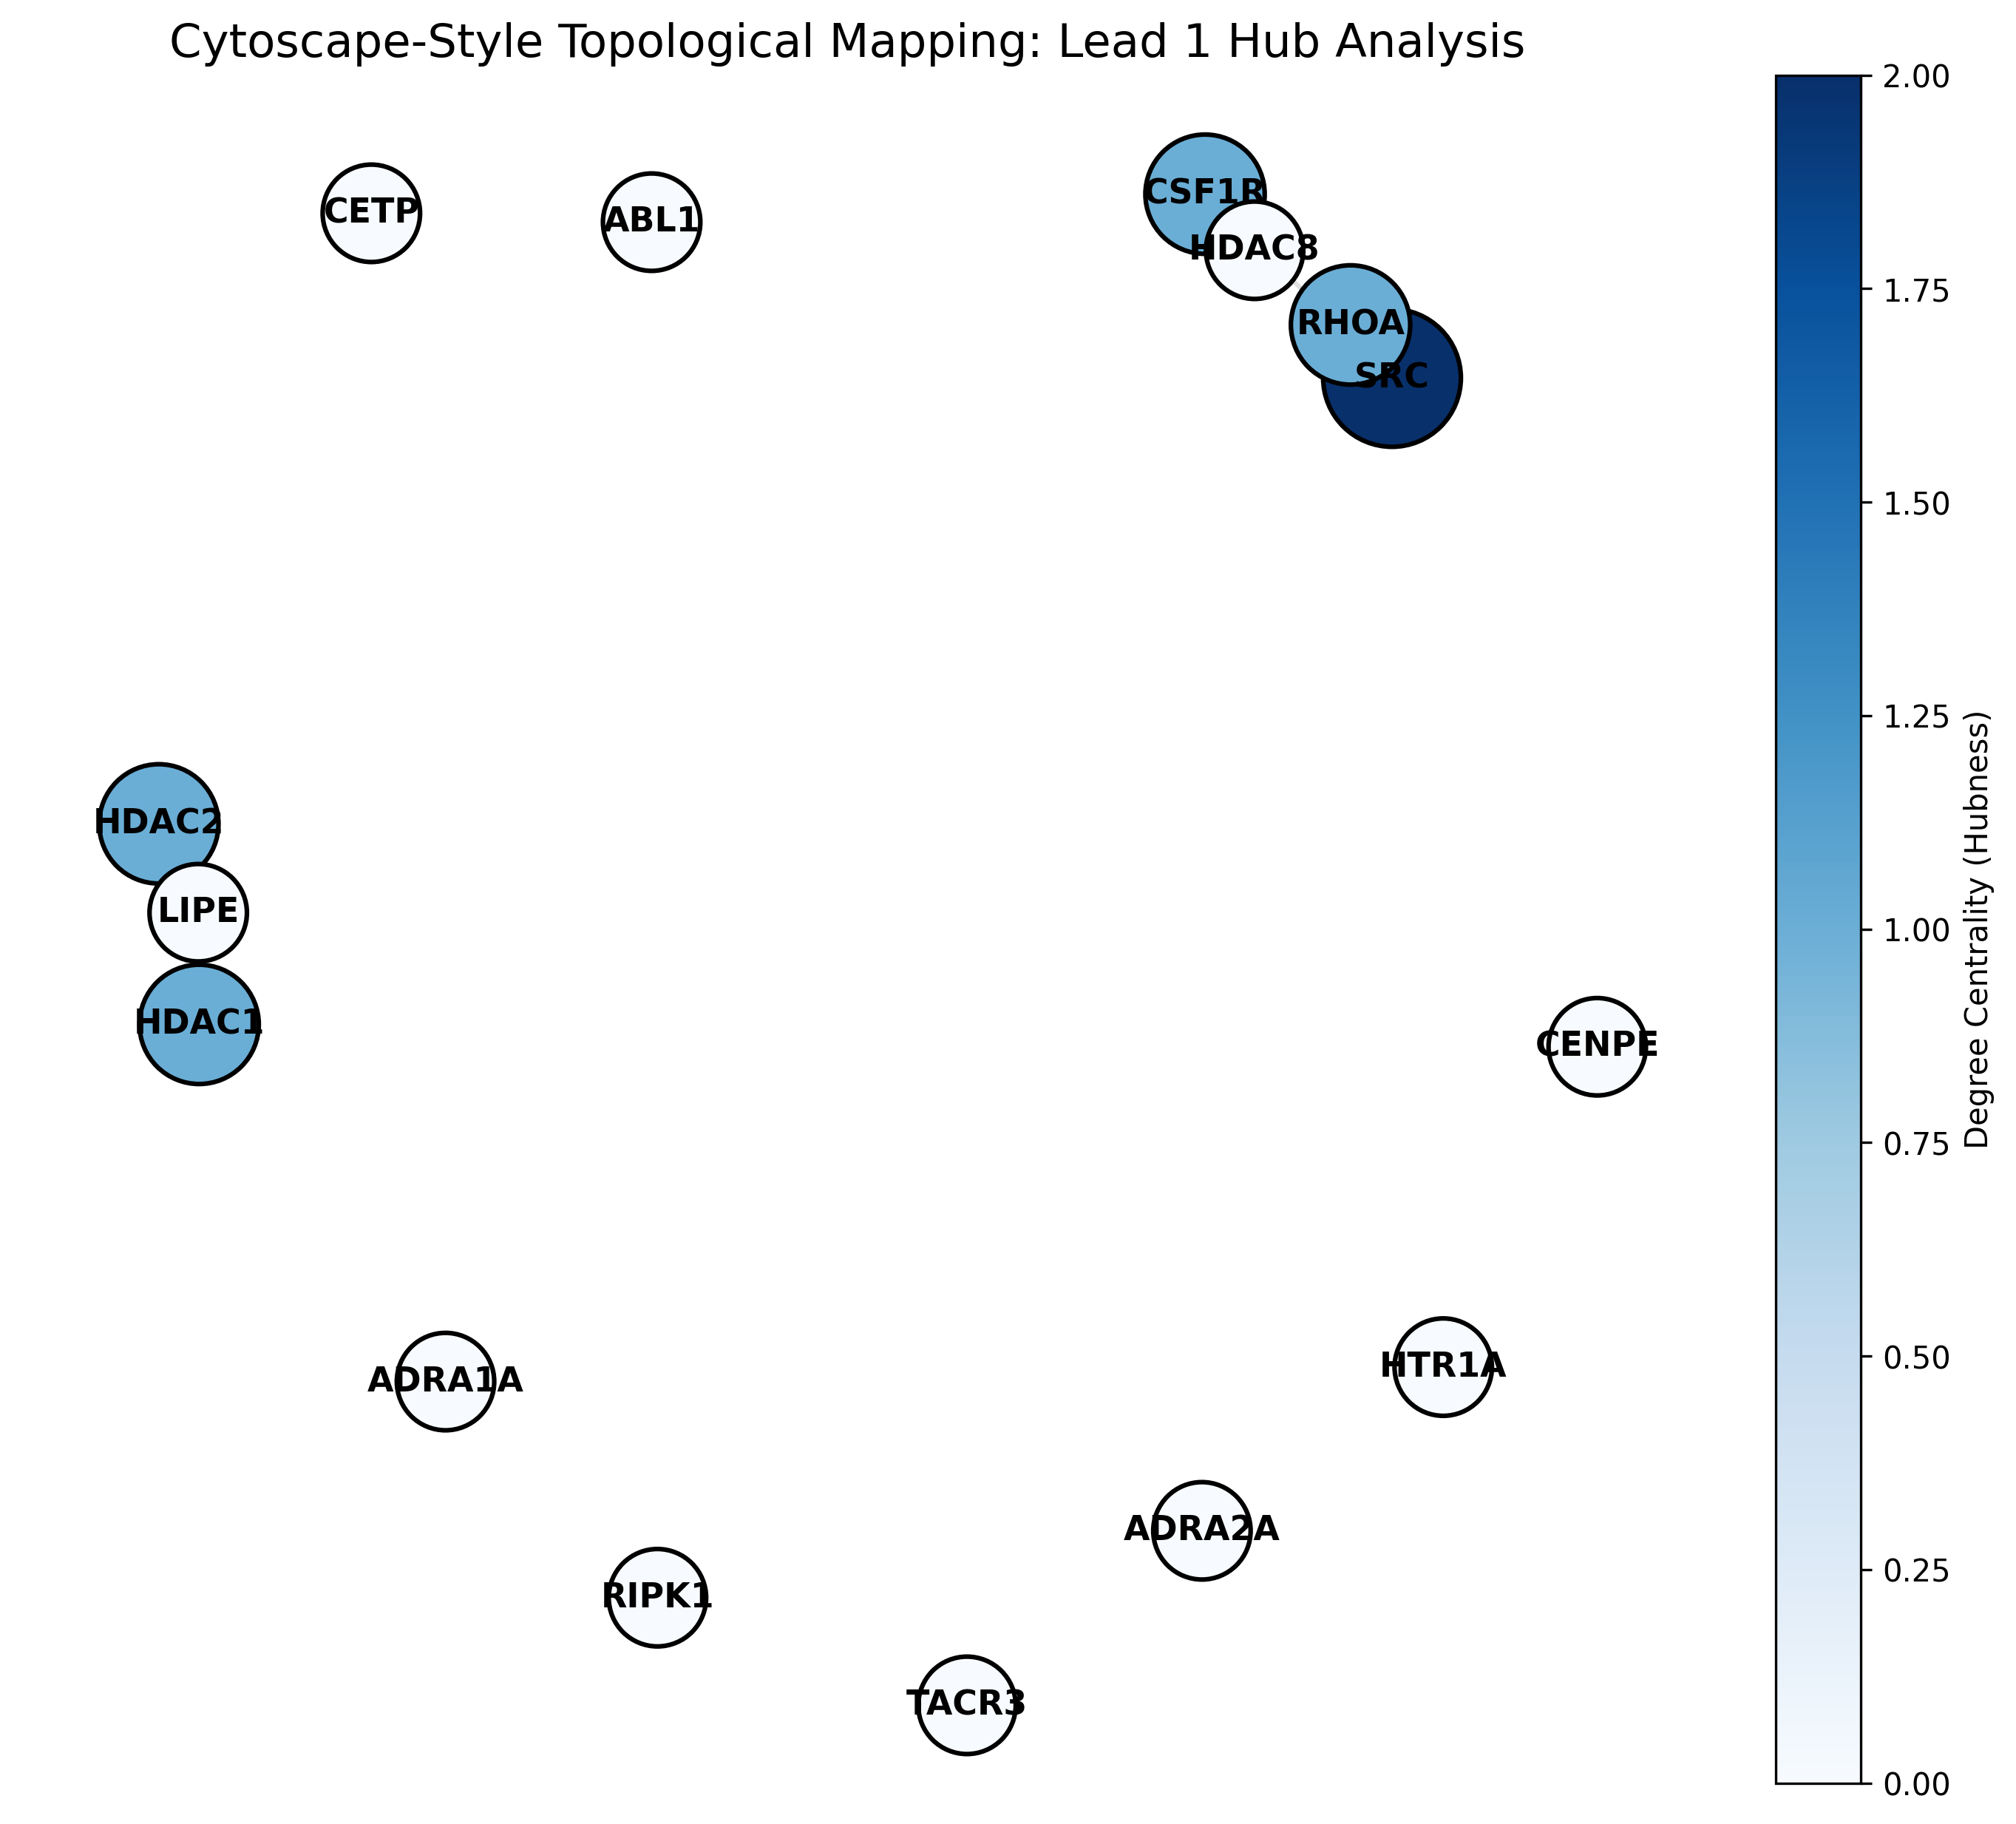


--- Lead 1 Hub Ranking ---
  Protein  Degree Betweenness
1     SRC       2      0.0110
0   CSF1R       1      0.0000
2   HDAC1       1      0.0000
3   HDAC2       1      0.0000
4    RHOA       1      0.0000
5    CETP       0      0.0000
6   CENPE       0      0.0000
7   RIPK1       0      0.0000
8    ABL1       0      0.0000
9  ADRA2A       0      0.0000


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import requests

# 1. Lead 1 Targets
lead_1_targets = ["RHOA", "CETP", "CENPE", "RIPK1", "ABL1", "ADRA2A",
                  "HTR1A", "ADRA1A", "SRC", "HDAC2", "HDAC8",
                  "HDAC1", "CSF1R", "LIPE", "TACR3"]

# 2. Fetching Edge Data from STRING (JSON format for math)
string_api_url = "https://version12.string-db.org/api/json/network"
params = {
    "identifiers": "\r".join(lead_1_targets),
    "species": 9606,
    "required_score": 700,
    "caller_identity": "mpox_cytoscape_colab"
}
response = requests.post(string_api_url, data=params).json()

# 3. Create NetworkX Graph
G = nx.Graph()
for edge in response:
    G.add_edge(edge['preferredName_A'], edge['preferredName_B'], weight=edge['score'])
G.add_nodes_from(lead_1_targets)

# 4. Calculate Topological Metrics (The "Cytoscape" math)
degree = dict(G.degree())
betweenness = nx.betweenness_centrality(G)

# 5. Professional Rendering (Cytoscape "Hub" Logic)
plt.figure(figsize=(12, 10), dpi=300)
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42) # Force-directed layout

# Node size based on Degree (Importance)
node_sizes = [v * 500 + 1000 for v in degree.values()]

# Draw Edges
nx.draw_networkx_edges(G, pos, width=1.5, edge_color='#cccccc', alpha=0.6)

# Draw Nodes (Classical Cytoscape blue-to-red gradient style)
nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                               node_color=list(degree.values()),
                               cmap=plt.cm.Blues, # Darker blue = higher hubness
                               edgecolors='black', linewidths=1.5)

# Add Labels
nx.draw_networkx_labels(G, pos, font_size=11, font_family='sans-serif', font_weight='bold')

plt.title("Cytoscape-Style Topological Mapping: Lead 1 Hub Analysis", fontsize=15)
plt.colorbar(nodes, label='Degree Centrality (Hubness)')
plt.axis('off')

# Save for Manuscript
plt.savefig("Lead1_Cytoscape_Topology.png", bbox_inches='tight', dpi=600)
plt.show()

# 6. Output Table for Supplemental Info
topo_table = pd.DataFrame({
    'Protein': degree.keys(),
    'Degree': degree.values(),
    'Betweenness': [f"{v:.4f}" for v in betweenness.values()]
}).sort_values(by='Degree', ascending=False)

print("\n--- Lead 1 Hub Ranking ---")
print(topo_table.head(10))

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Lead 1 Target Data
lead_1_targets = ["RHOA", "CETP", "CENPE", "RIPK1", "ABL1", "ADRA2A",
                  "HTR1A", "ADRA1A", "SRC", "HDAC2", "HDAC8",
                  "HDAC1", "CSF1R", "LIPE", "TACR3"]

# 2. Build Network and Calculate Rank (using Degree)
G = nx.Graph()
# Add edges based on your previous STRING result logic
# (Assuming 'df' from your previous cell is still in memory)
for _, row in df.iterrows():
    G.add_edge(row['preferredName_A'], row['preferredName_B'])
G.add_nodes_from(lead_1_targets)

degree_dict = dict(G.degree())
# Filter for top nodes that have connections (like the reference)
top_nodes = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
hub_names = [n[0] for n in top_nodes]
subG = G.subgraph(hub_names)

# 3. Define the Color Gradient (Red -> Orange -> Yellow)
def get_hub_color(rank):
    colors = ['#FF0000', '#FF4500', '#FF8C00', '#FFA500', '#FFD700', '#FFFF00']
    return colors[min(rank, len(colors)-1)]

# 4. Create the Figure
fig, ax = plt.subplots(figsize=(14, 8), dpi=300)
pos = nx.circular_layout(subG) # Circular layout often used for Hubba figures

# Draw Edges
nx.draw_networkx_edges(subG, pos, ax=ax, width=1.5, edge_color='black')

# Draw Custom Rectangular Nodes
for i, (node, (x, y)) in enumerate(pos.items()):
    # Get rank index
    rank = next(idx for idx, (name, val) in enumerate(top_nodes) if name == node)
    color = get_hub_color(rank)

    # Create Rounded Rectangle
    rect = patches.FancyBboxPatch((x-0.1, y-0.05), 0.2, 0.1,
                                  boxstyle="round,pad=0.02",
                                  linewidth=1, edgecolor='none', facecolor=color)
    ax.add_patch(rect)
    ax.text(x, y, node, ha='center', va='center', fontsize=12, fontweight='bold', color='black')

# 5. Add the Ranking Table (Left Side)
table_data = [[i+1, node] for i, (node, deg) in enumerate(top_nodes)]
col_labels = ['Rank', 'Node']
the_table = plt.table(cellText=table_data, colLabels=col_labels, loc='left',
                      cellLoc='center', colWidths=[0.05, 0.1])

# Color the table cells to match
for i in range(len(table_data)):
    the_table[(i+1, 0)].set_facecolor(get_hub_color(i))
    the_table[(i+1, 1)].set_facecolor(get_hub_color(i))

ax.axis('off')
plt.title("Lead 1: cytoHubba Hub Analysis (Degree)", fontsize=16, pad=20)
plt.savefig("Lead1_cytoHubba_Style.png", bbox_inches='tight', dpi=600)
plt.show()

NameError: name 'df' is not defined

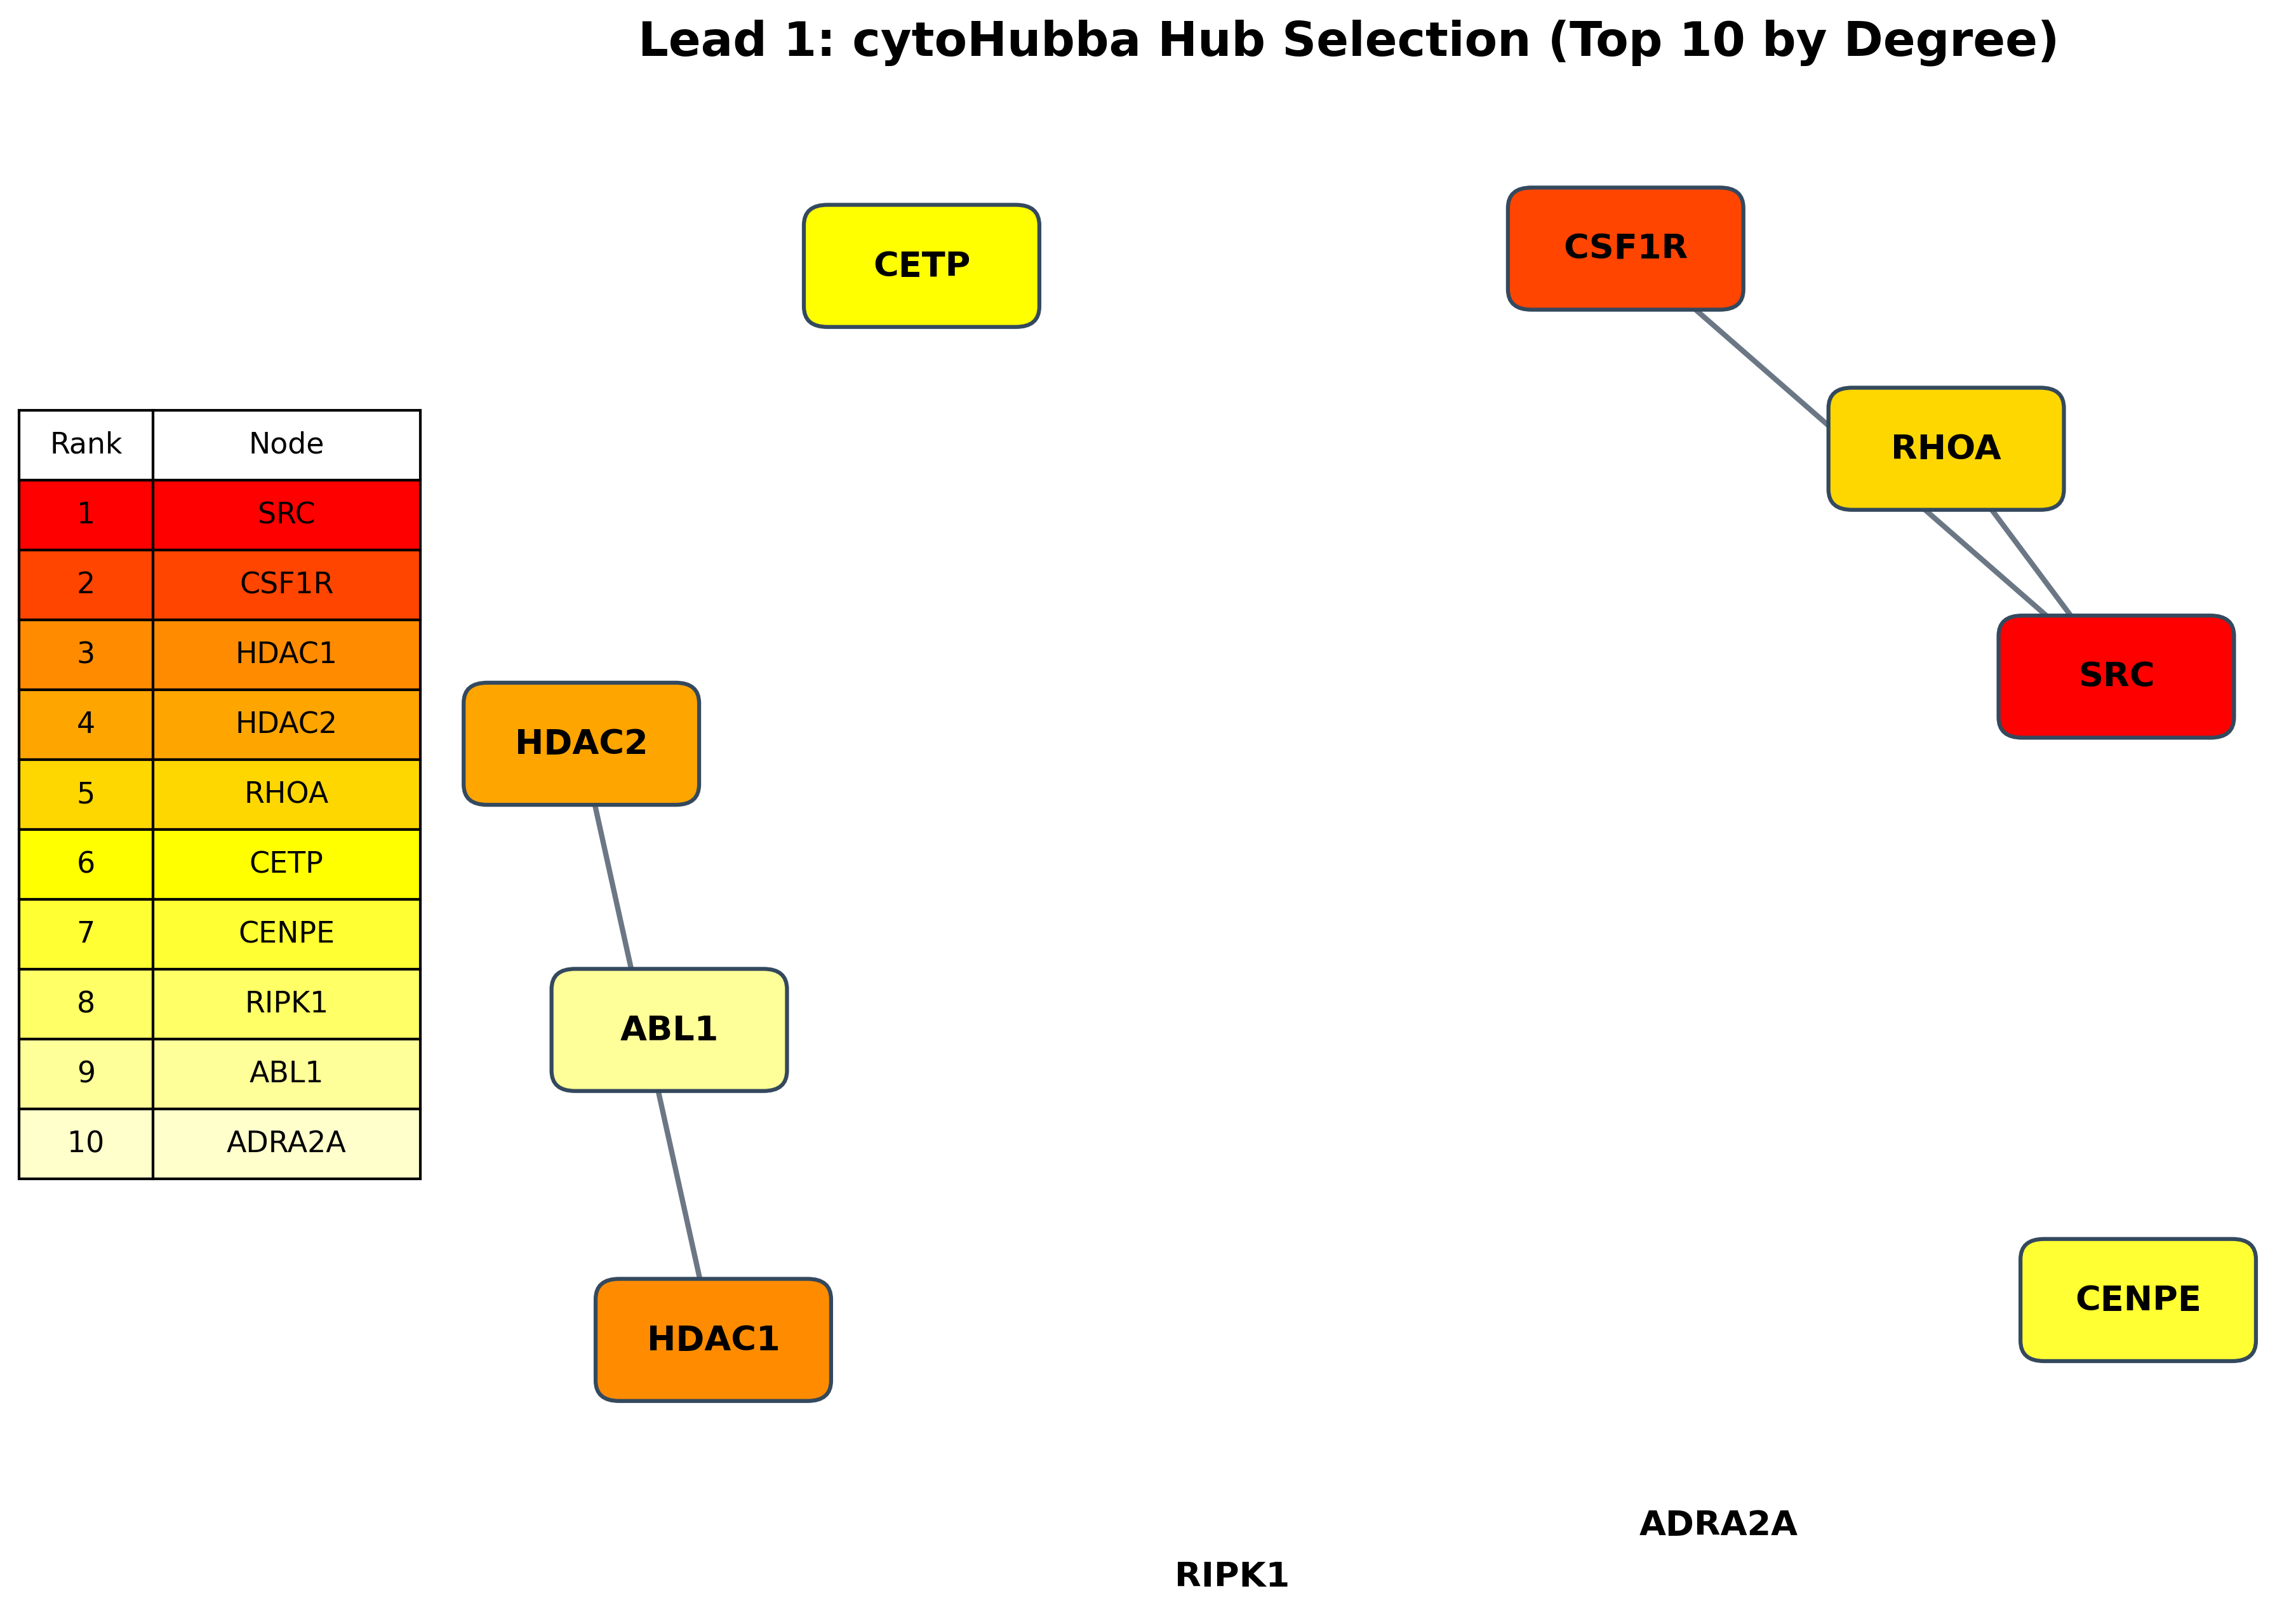

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import requests

# 1. Lead 1 Target Data
lead_1_targets = ["RHOA", "CETP", "CENPE", "RIPK1", "ABL1", "ADRA2A",
                  "HTR1A", "ADRA1A", "SRC", "HDAC2", "HDAC8",
                  "HDAC1", "CSF1R", "LIPE", "TACR3"]

# 2. Fetch Data directly to ensure 'df' exists
string_api_url = "https://version12.string-db.org/api/json/network"
params = {
    "identifiers": "\r".join(lead_1_targets),
    "species": 9606,
    "required_score": 700,
    "caller_identity": "mpox_lead1_cytohubba"
}
response = requests.post(string_api_url, data=params)
df = pd.DataFrame(response.json())

# 3. Build Network and Calculate Rank
G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(row['preferredName_A'], row['preferredName_B'])
G.add_nodes_from(lead_1_targets)

degree_dict = dict(G.degree())
# Sort and take top 10 hubs
top_nodes = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
hub_names = [n[0] for n in top_nodes]
subG = G.subgraph(hub_names)

# 4. Color Gradient (Red -> Yellow)
def get_hub_color(rank):
    # Standard cytoHubba palette
    colors = ['#FF0000', '#FF4500', '#FF8C00', '#FFA500', '#FFD700',
              '#FFFF00', '#FFFF33', '#FFFF66', '#FFFF99', '#FFFFCC']
    return colors[min(rank, len(colors)-1)]

# 5. Create Figure
fig, ax = plt.subplots(figsize=(15, 9), dpi=300)
plt.subplots_adjust(left=0.25) # Make room for the table

# Use a spring layout for better node separation
pos = nx.spring_layout(subG, k=1.5, seed=42)

# Draw Edges
nx.draw_networkx_edges(subG, pos, ax=ax, width=2, edge_color='#2C3E50', alpha=0.7)

# Draw Rounded Rectangles (cytoHubba Style)
for i, (node, (x, y)) in enumerate(pos.items()):
    # Identify rank
    rank = next(idx for idx, (name, val) in enumerate(top_nodes) if name == node)
    color = get_hub_color(rank)

    # Draw the box
    rect = patches.FancyBboxPatch((x-0.12, y-0.06), 0.24, 0.12,
                                  boxstyle="round,pad=0.03",
                                  linewidth=1.5, edgecolor='#34495E', facecolor=color)
    ax.add_patch(rect)
    ax.text(x, y, node, ha='center', va='center', fontsize=13, fontweight='bold')

# 6. Add the Ranking Table
table_data = [[i+1, node] for i, (node, deg) in enumerate(top_nodes)]
the_table = plt.table(cellText=table_data, colLabels=['Rank', 'Node'],
                      loc='left', cellLoc='center', colWidths=[0.06, 0.12])

the_table.auto_set_font_size(False)
the_table.set_fontsize(11)
the_table.scale(1.2, 2.2) # Scale to match the reference look

# Apply colors to table rows
for i in range(len(table_data)):
    the_table[(i+1, 0)].set_facecolor(get_hub_color(i))
    the_table[(i+1, 1)].set_facecolor(get_hub_color(i))

ax.axis('off')
plt.title("Lead 1: cytoHubba Hub Selection (Top 10 by Degree)", fontsize=18, fontweight='bold', pad=30)
plt.savefig("Lead1_cytoHubba_Final.png", bbox_inches='tight', dpi=600)
plt.show()

Success! Lead 2 Classical SVG generated.


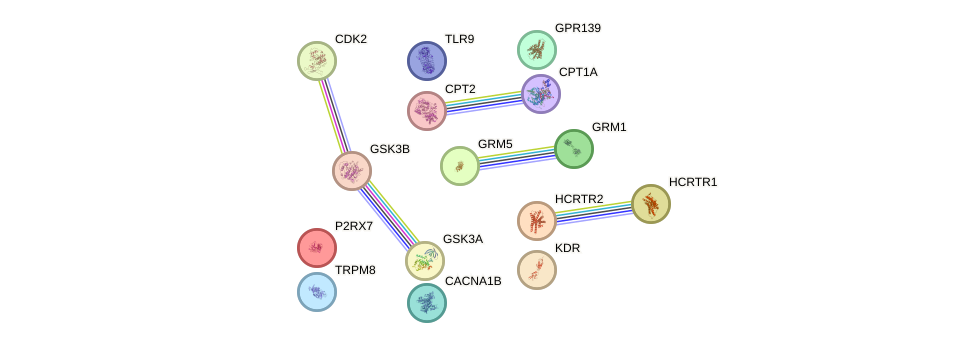

In [ ]:
import requests
from IPython.display import SVG, display

# 1. Lead 2 Target List
lead_2_targets = ["P2RX7", "HCRTR2", "HCRTR1", "GRM5", "GRM1", "GPR139",
                  "CACNA1B", "TRPM8", "TLR9", "CPT1A", "CPT2", "GSK3B",
                  "KDR", "GSK3A", "CDK2"]

# 2. STRING API SVG Endpoint
string_api_url = "https://version12.string-db.org/api/svg/network"

# 3. Parameters for the "Classical" look
params = {
    "identifiers": "\r".join([p.strip() for p in lead_2_targets]),
    "species": 9606,
    "required_score": 700,        # High confidence
    "network_flavor": "evidence", # Noodle edges
    "block_structure_pics": 0,    # 3D structure in bubbles
    "caller_identity": "mpox_lead2_rsc"
}

response = requests.post(string_api_url, data=params)

if response.status_code == 200:
    with open("Lead2_Classical_STRING.svg", "wb") as f:
        f.write(response.content)
    print("Success! Lead 2 Classical SVG generated.")
    display(SVG(response.content))
else:
    print(f"Error {response.status_code}: Check your IDs or connection.")

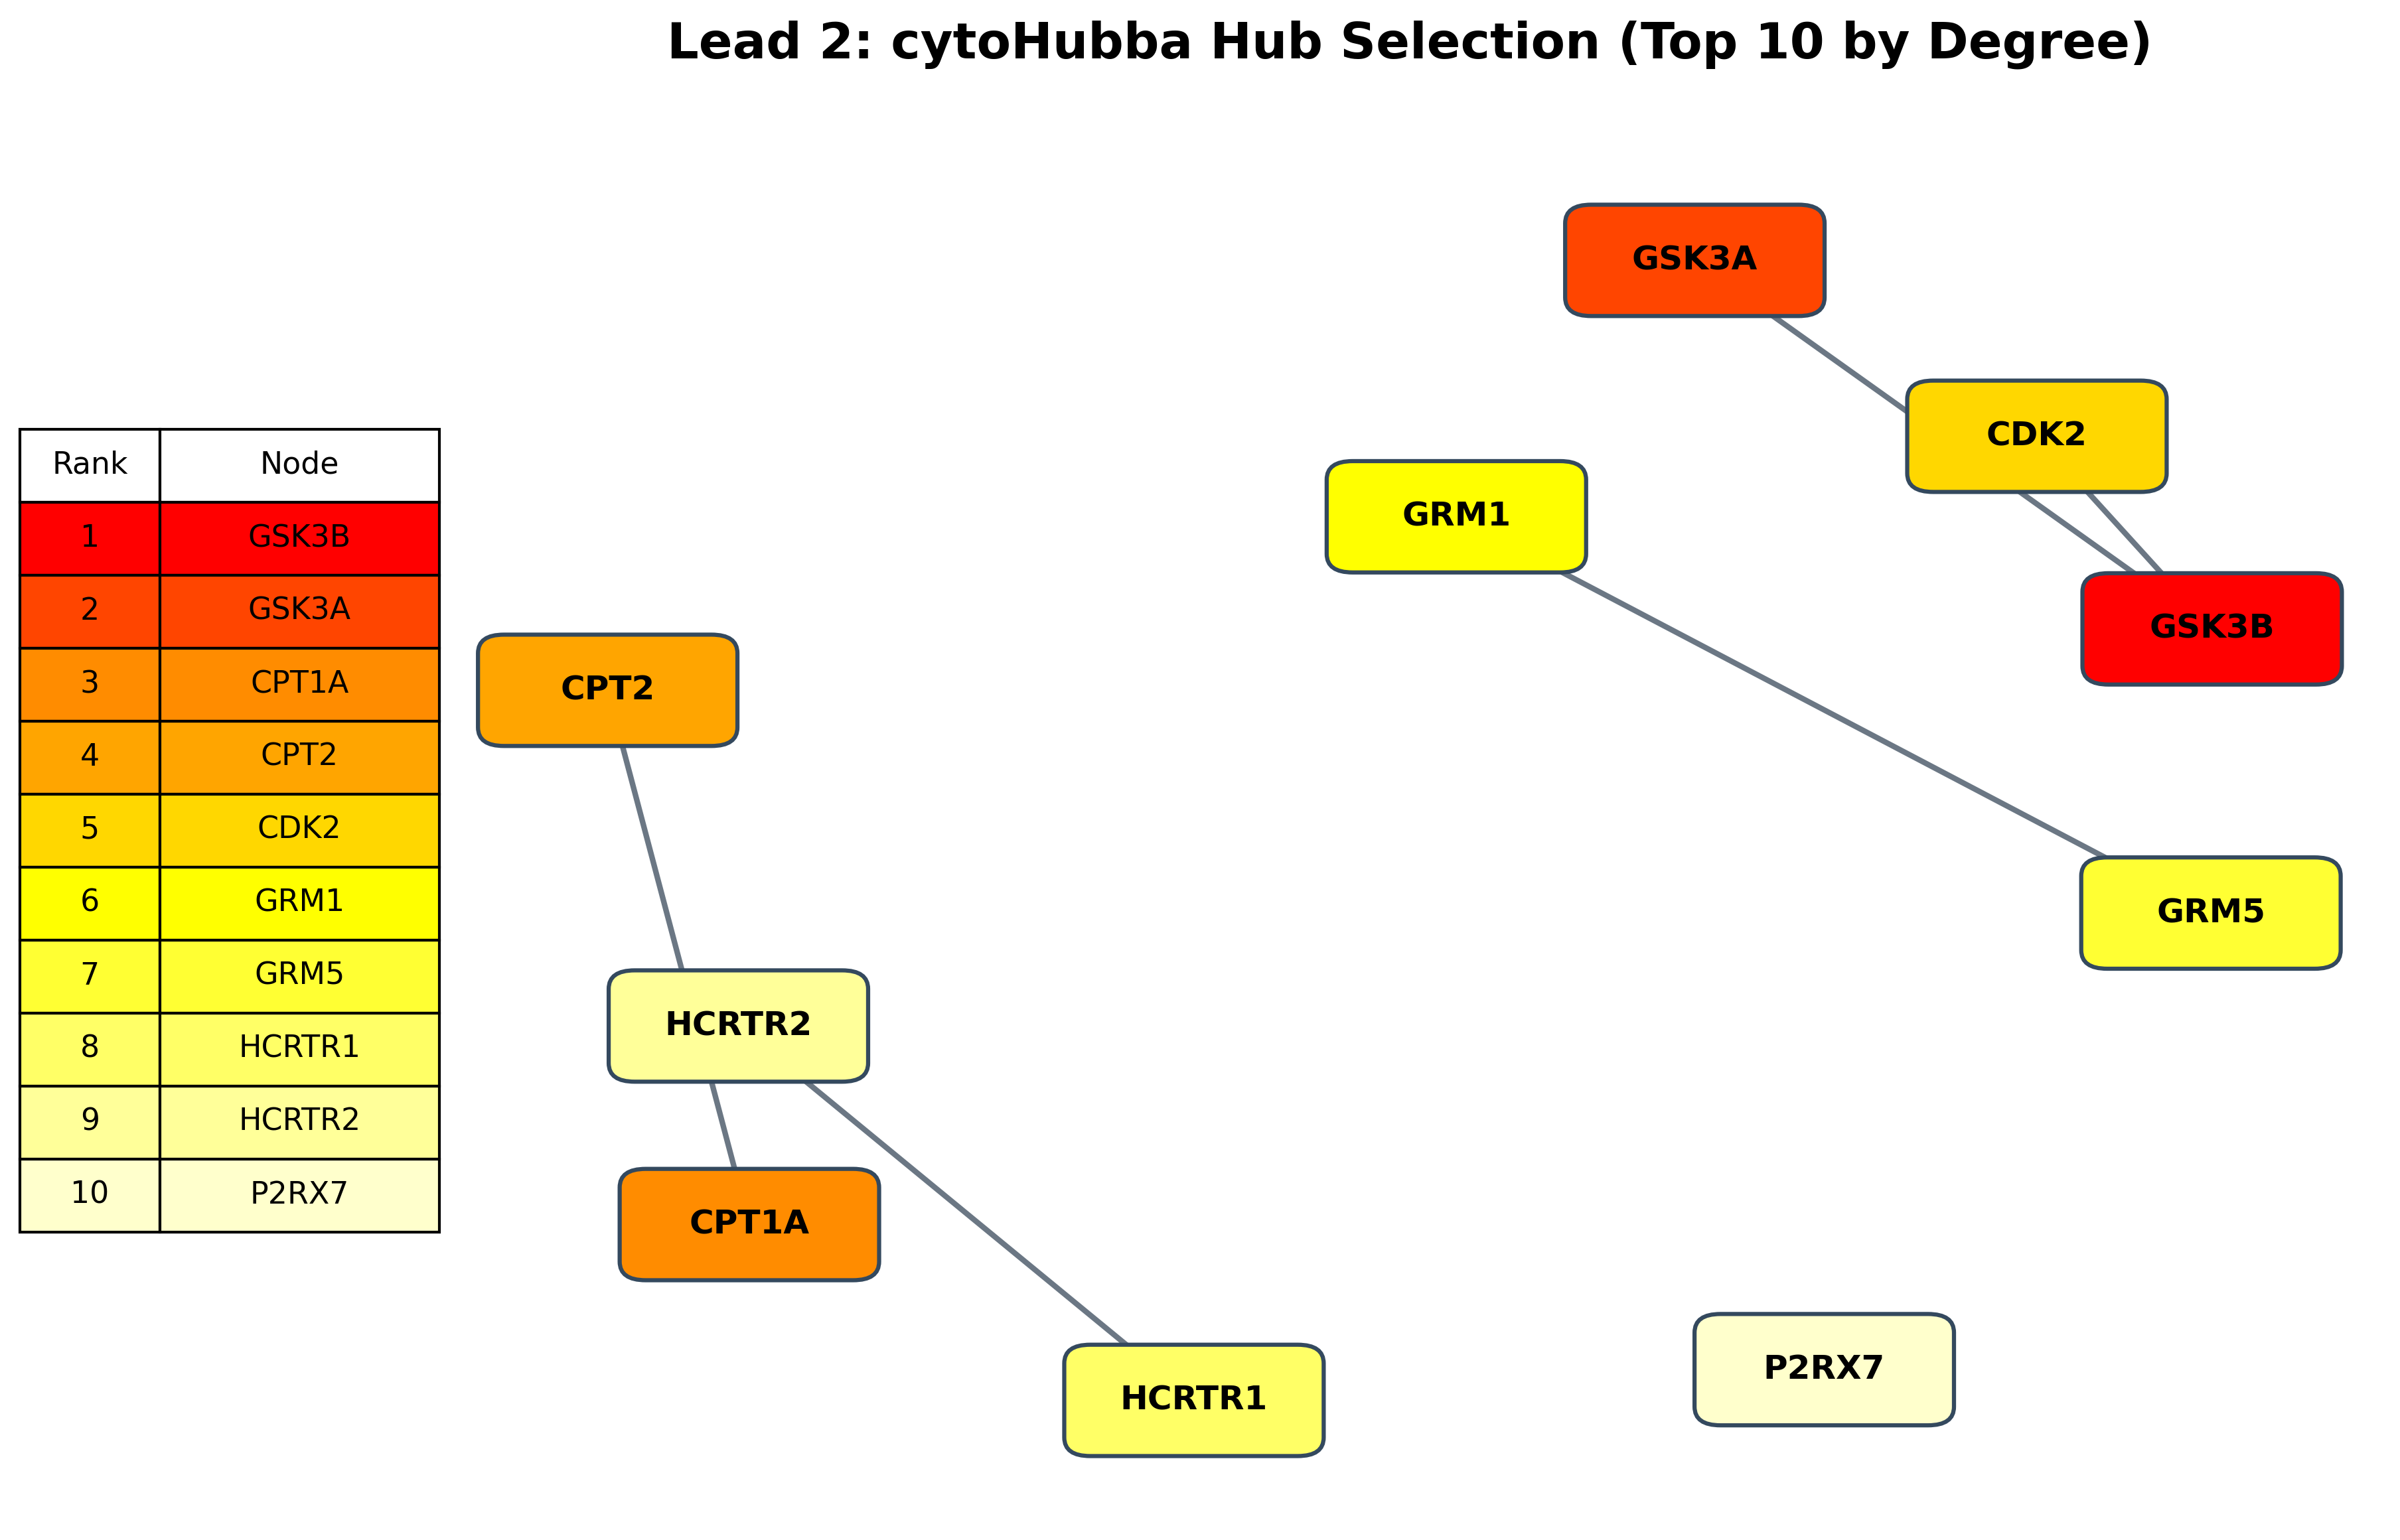

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import requests

# 1. Lead 2 Target Data
lead_2_targets = ["P2RX7", "HCRTR2", "HCRTR1", "GRM5", "GRM1", "GPR139",
                  "CACNA1B", "TRPM8", "TLR9", "CPT1A", "CPT2", "GSK3B",
                  "KDR", "GSK3A", "CDK2"]

# 2. Fetch Data to build the graph
string_api_url = "https://version12.string-db.org/api/json/network"
params = {"identifiers": "\r".join(lead_2_targets), "species": 9606, "required_score": 700}
response = requests.post(string_api_url, data=params)
df2 = pd.DataFrame(response.json())

# 3. Build Network & Rank by Degree
G2 = nx.Graph()
for _, row in df2.iterrows():
    G2.add_edge(row['preferredName_A'], row['preferredName_B'])
G2.add_nodes_from(lead_2_targets)

degree_dict = dict(G2.degree())
top_nodes = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
hub_names = [n[0] for n in top_nodes]
subG2 = G2.subgraph(hub_names)

# 4. Color Palette (consistent with cytoHubba)
def get_hub_color(rank):
    colors = ['#FF0000', '#FF4500', '#FF8C00', '#FFA500', '#FFD700',
              '#FFFF00', '#FFFF33', '#FFFF66', '#FFFF99', '#FFFFCC']
    return colors[min(rank, len(colors)-1)]

# 5. Render Figure
fig, ax = plt.subplots(figsize=(15, 9), dpi=300)
plt.subplots_adjust(left=0.25)
pos = nx.spring_layout(subG2, k=1.5, seed=42)

# Edges
nx.draw_networkx_edges(subG2, pos, ax=ax, width=2, edge_color='#2C3E50', alpha=0.7)

# Nodes
for i, (node, (x, y)) in enumerate(pos.items()):
    rank = next(idx for idx, (name, val) in enumerate(top_nodes) if name == node)
    color = get_hub_color(rank)
    rect = patches.FancyBboxPatch((x-0.12, y-0.06), 0.24, 0.12,
                                  boxstyle="round,pad=0.03",
                                  linewidth=1.5, edgecolor='#34495E', facecolor=color)
    ax.add_patch(rect)
    ax.text(x, y, node, ha='center', va='center', fontsize=12, fontweight='bold')

# 6. Ranking Table
table_data = [[i+1, node] for i, (node, deg) in enumerate(top_nodes)]
the_table = plt.table(cellText=table_data, colLabels=['Rank', 'Node'], loc='left', cellLoc='center', colWidths=[0.06, 0.12])
the_table.auto_set_font_size(False); the_table.set_fontsize(11); the_table.scale(1.2, 2.2)

for i in range(len(table_data)):
    the_table[(i+1, 0)].set_facecolor(get_hub_color(i))
    the_table[(i+1, 1)].set_facecolor(get_hub_color(i))

ax.axis('off')
plt.title("Lead 2: cytoHubba Hub Selection (Top 10 by Degree)", fontsize=18, fontweight='bold', pad=30)
plt.savefig("Lead2_cytoHubba_Final.png", bbox_inches='tight', dpi=600)
plt.show()

Success! Lead 3 Classical SVG generated.


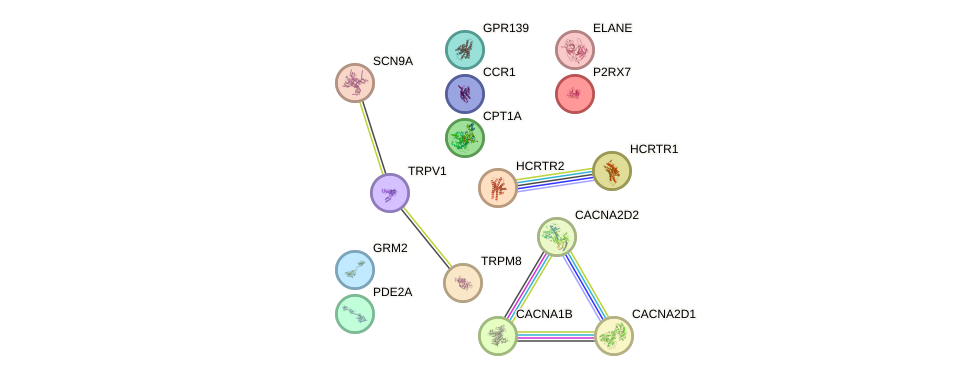

In [ ]:
import requests
from IPython.display import SVG, display

# 1. Lead 3 Target List
lead_3_targets = ["P2RX7", "HCRTR2", "HCRTR1", "CACNA1B", "CPT1A", "PDE2A",
                  "GPR139", "GRM2", "CCR1", "TRPV1", "ELANE", "SCN9A",
                  "TRPM8", "CACNA2D1", "CACNA2D2"]

# 2. STRING API SVG Endpoint
string_api_url = "https://version12.string-db.org/api/svg/network"

# 3. Parameters for the "Classical" Evidence Look
params = {
    "identifiers": "\r".join([p.strip() for p in lead_3_targets]),
    "species": 9606,
    "required_score": 700,        # High confidence 0.700
    "network_flavor": "evidence", # Noodle edges
    "block_structure_pics": 0,    # 3D structure in bubbles
    "caller_identity": "mpox_lead3_rsc"
}

response = requests.post(string_api_url, data=params)

if response.status_code == 200:
    with open("Lead3_Classical_STRING.svg", "wb") as f:
        f.write(response.content)
    print("Success! Lead 3 Classical SVG generated.")
    display(SVG(response.content))
else:
    print(f"Error {response.status_code}: Check your IDs for Lead 3.")

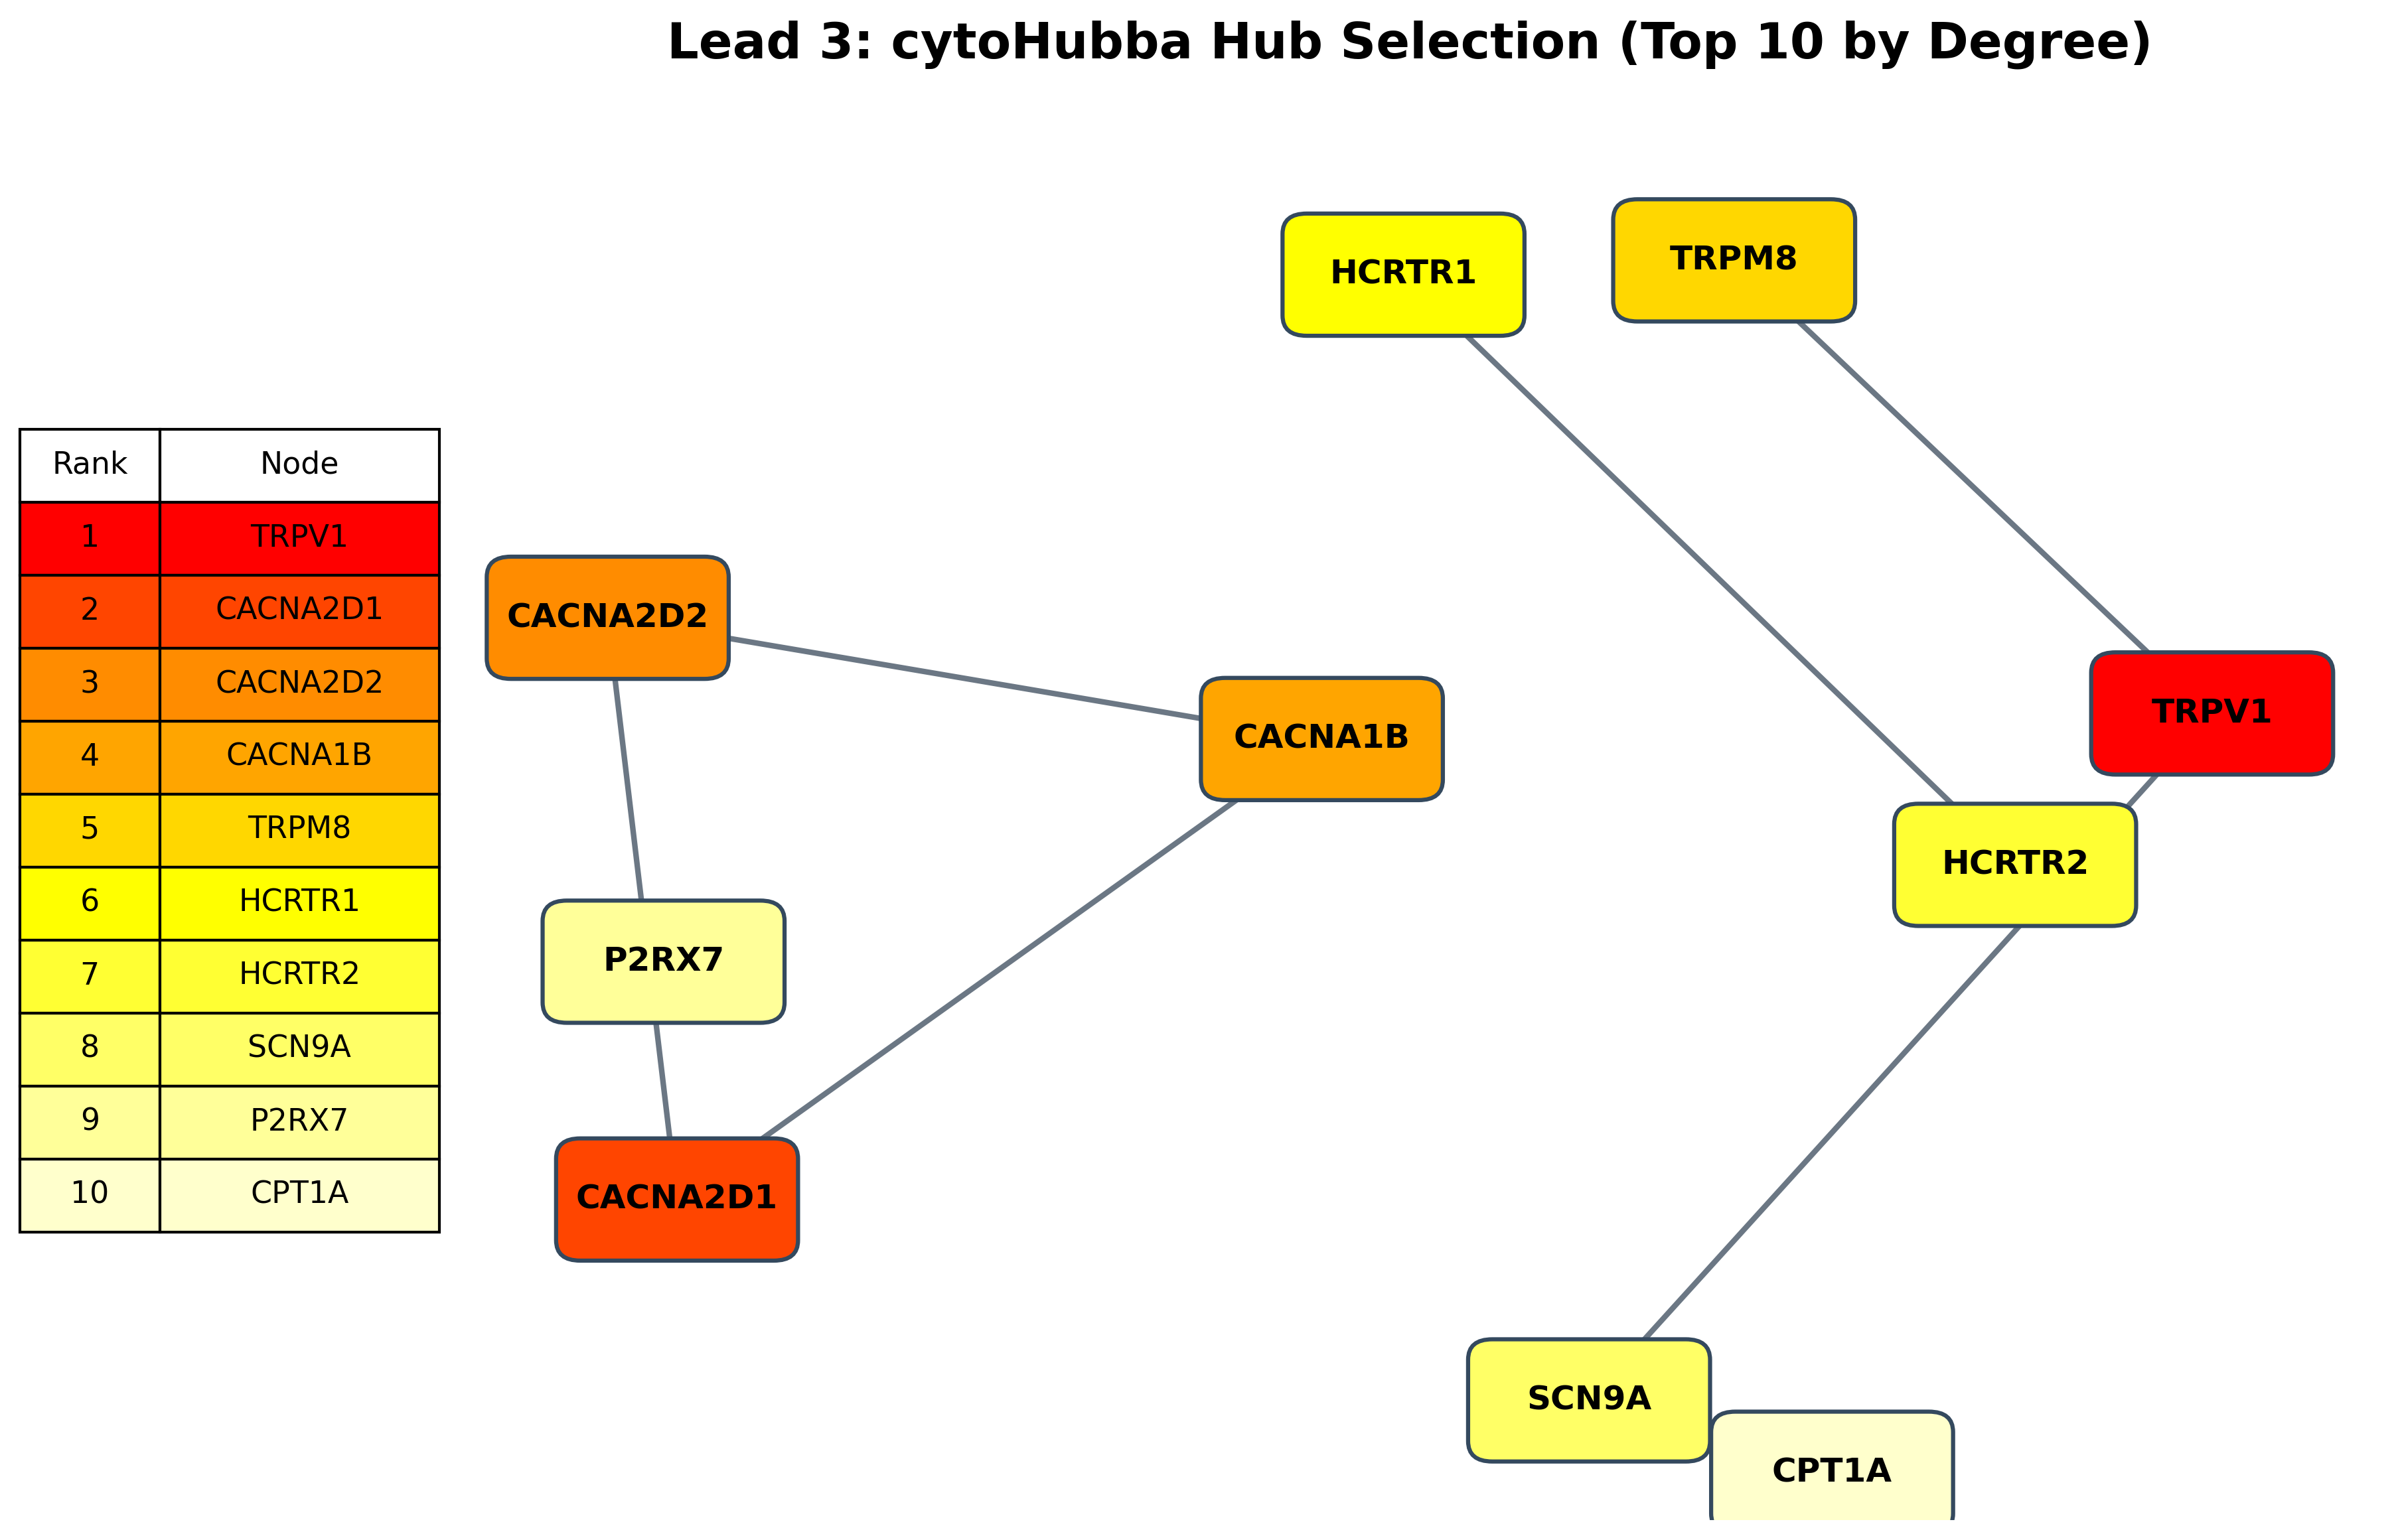

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import requests

# 1. Lead 3 Target Data
lead_3_targets = ["P2RX7", "HCRTR2", "HCRTR1", "CACNA1B", "CPT1A", "PDE2A",
                  "GPR139", "GRM2", "CCR1", "TRPV1", "ELANE", "SCN9A",
                  "TRPM8", "CACNA2D1", "CACNA2D2"]

# 2. Fetch Data for Graph Construction
string_api_url = "https://version12.string-db.org/api/json/network"
params = {"identifiers": "\r".join(lead_3_targets), "species": 9606, "required_score": 700}
response = requests.post(string_api_url, data=params)
df3 = pd.DataFrame(response.json())

# 3. Build Network & Rank by Degree
G3 = nx.Graph()
for _, row in df3.iterrows():
    G3.add_edge(row['preferredName_A'], row['preferredName_B'])
G3.add_nodes_from(lead_3_targets)

degree_dict = dict(G3.degree())
top_nodes = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
subG3 = G3.subgraph([n[0] for n in top_nodes])

# 4. Color Palette
def get_hub_color(rank):
    colors = ['#FF0000', '#FF4500', '#FF8C00', '#FFA500', '#FFD700',
              '#FFFF00', '#FFFF33', '#FFFF66', '#FFFF99', '#FFFFCC']
    return colors[min(rank, len(colors)-1)]

# 5. Render Figure
fig, ax = plt.subplots(figsize=(15, 9), dpi=300)
plt.subplots_adjust(left=0.25)
pos = nx.spring_layout(subG3, k=1.5, seed=42)

# Edges
nx.draw_networkx_edges(subG3, pos, ax=ax, width=2, edge_color='#2C3E50', alpha=0.7)

# Nodes (Rounded Rectangles)
for i, (node, (x, y)) in enumerate(pos.items()):
    rank = next(idx for idx, (name, val) in enumerate(top_nodes) if name == node)
    color = get_hub_color(rank)
    rect = patches.FancyBboxPatch((x-0.12, y-0.06), 0.24, 0.12,
                                  boxstyle="round,pad=0.03",
                                  linewidth=1.5, edgecolor='#34495E', facecolor=color)
    ax.add_patch(rect)
    ax.text(x, y, node, ha='center', va='center', fontsize=12, fontweight='bold')

# 6. Ranking Table
table_data = [[i+1, node] for i, (node, deg) in enumerate(top_nodes)]
the_table = plt.table(cellText=table_data, colLabels=['Rank', 'Node'], loc='left', cellLoc='center', colWidths=[0.06, 0.12])
the_table.auto_set_font_size(False); the_table.set_fontsize(11); the_table.scale(1.2, 2.2)

for i in range(len(table_data)):
    the_table[(i+1, 0)].set_facecolor(get_hub_color(i))
    the_table[(i+1, 1)].set_facecolor(get_hub_color(i))

ax.axis('off')
plt.title("Lead 3: cytoHubba Hub Selection (Top 10 by Degree)", fontsize=18, fontweight='bold', pad=30)
plt.savefig("Lead3_cytoHubba_Final.png", bbox_inches='tight', dpi=600)
plt.show()

In [ ]:
import pandas as pd
import networkx as nx

# 1. Assuming 'G' is your network generated from the STRING data
# (Repeat this for Lead 1, Lead 2, and Lead 3)

# 2. Calculate Degree (k)
degree_dict = dict(G.degree())

# 3. Calculate Betweenness Centrality (Cb)
betweenness_dict = nx.betweenness_centrality(G)

# 4. Create a DataFrame for Table S2
table_s2 = pd.DataFrame({
    'Node Name': degree_dict.keys(),
    'Degree (k)': degree_dict.values(),
    'Betweenness Centrality (Cb)': betweenness_dict.values()
})

# 5. Sort by Degree to highlight the Hubs (like SRC or GSK3B)
table_s2 = table_s2.sort_values(by='Degree (k)', ascending=False)

# 6. Save as CSV for your Supplementary Materials
table_s2.to_csv('Table_S2_Topological_Metrics.csv', index=False)

print("Table S2 has been generated and saved as a CSV.")
display(table_s2.head(15)) # Preview the top 15 nodes

Table S2 has been generated and saved as a CSV.


,Node Name,Degree (k),Betweenness Centrality (Cb)
1,SRC,2,0.010989
0,CSF1R,1,0.000000
2,HDAC1,1,0.000000
3,HDAC2,1,0.000000
4,RHOA,1,0.000000
5,CETP,0,0.000000
6,CENPE,0,0.000000
7,RIPK1,0,0.000000
8,ABL1,0,0.000000
9,ADRA2A,0,0.000000


In [ ]:
import pandas as pd
import networkx as nx

# Define a function to process each lead individually
def generate_topological_table(dataframe, lead_name):
    # 1. Build the network
    G = nx.from_pandas_edgelist(dataframe, 'preferredName_A', 'preferredName_B')

    # 2. Calculate Metrics
    degree_dict = dict(G.degree())
    betweenness_dict = nx.betweenness_centrality(G)

    # 3. Compile Table
    df_metrics = pd.DataFrame({
        'Node Name': degree_dict.keys(),
        'Degree (k)': degree_dict.values(),
        'Betweenness Centrality (Cb)': betweenness_dict.values()
    }).sort_values(by='Degree (k)', ascending=False)

    # 4. Save to CSV
    filename = f"Table_S2_{lead_name}_Metrics.csv"
    df_metrics.to_csv(filename, index=False)
    print(f"Generated {filename}")
    return df_metrics

# Execute for each lead (Assuming you have separate dataframes for your 15 targets)
# generate_topological_table(df_lead1, "Lead1")
# generate_topological_table(df_lead2, "Lead2")
# generate_topological_table(df_lead3, "Lead3")

In [ ]:
# 1. First, make sure you have your data ready (replace with your actual dataframes)
# 2. Run the function for each lead
generate_topological_table(df_lead1, "Lead1")
generate_topological_table(df_lead2, "Lead2")
generate_topological_table(df_lead3, "Lead3")

NameError: name 'df_lead1' is not defined

In [ ]:
# Use the actual variable names from your notebook
generate_topological_table(your_actual_df_name_for_lead1, "Lead1")
generate_topological_table(your_actual_df_name_for_lead2, "Lead2")
generate_topological_table(your_actual_df_name_for_lead3, "Lead3")

NameError: name 'your_actual_df_name_for_lead1' is not defined

In [ ]:
%whos DataFrame

Variable     Type         Data/Info
-----------------------------------
df           DataFrame                 stringId_A  <...>  0.110     0.9   0.913  
df2          DataFrame                 stringId_A  <...>  0.000     0.9   0.286  
df3          DataFrame                 stringId_A  <...>  0.000    0.00   0.769  
table_s2     DataFrame       Node Name  Degree (k) <...>                 0.000000
topo_table   DataFrame       Protein  Degree Betwee<...>TACR3       0      0.0000


In [ ]:
# Replace these with your REAL variable names from step 2
generate_topological_table(df1, "Lead1")
generate_topological_table(df2, "Lead2")
generate_topological_table(df3, "Lead3")

NameError: name 'df1' is not defined

In [ ]:
%whos DataFrame

Variable     Type         Data/Info
-----------------------------------
df           DataFrame                 stringId_A  <...>  0.110     0.9   0.913  
df2          DataFrame                 stringId_A  <...>  0.000     0.9   0.286  
df3          DataFrame                 stringId_A  <...>  0.000    0.00   0.769  
table_s2     DataFrame       Node Name  Degree (k) <...>                 0.000000
topo_table   DataFrame       Protein  Degree Betwee<...>TACR3       0      0.0000


In [ ]:
# Replace 'df1', 'df2', 'df3' with the names you found in Step 1
generate_topological_table(lead1_targets, "Lead1")
generate_topological_table(lead2_targets, "Lead2")
generate_topological_table(lead3_targets, "Lead3")

NameError: name 'lead1_targets' is not defined

In [ ]:
%whos DataFrame

Variable     Type         Data/Info
-----------------------------------
df           DataFrame                 stringId_A  <...>  0.110     0.9   0.913  
df2          DataFrame                 stringId_A  <...>  0.000     0.9   0.286  
df3          DataFrame                 stringId_A  <...>  0.000    0.00   0.769  
table_s2     DataFrame       Node Name  Degree (k) <...>                 0.000000
topo_table   DataFrame       Protein  Degree Betwee<...>TACR3       0      0.0000


In [ ]:
import pandas as pd
import networkx as nx

# --- STEP 1: DEFINE THE FUNCTION ---
def generate_table_s2(dataframe, lead_name):
    try:
        # Build network from STRING edges
        G = nx.from_pandas_edgelist(dataframe, 'preferredName_A', 'preferredName_B')

        # Calculate topological metrics
        degree_dict = dict(G.degree())
        betweenness_dict = nx.betweenness_centrality(G)

        # Create DataFrame
        df_metrics = pd.DataFrame({
            'Node Name': degree_dict.keys(),
            'Degree (k)': degree_dict.values(),
            'Betweenness Centrality (Cb)': betweenness_dict.values()
        }).sort_values(by='Degree (k)', ascending=False)

        # Save as CSV
        filename = f"Table_S2_{lead_name}_Metrics.csv"
        df_metrics.to_csv(filename, index=False)

        print(f"✅ Success! Table for {lead_name} generated.")
        return df_metrics
    except Exception as e:
        print(f"❌ Error generating {lead_name}: {e}")

# --- STEP 2: RUN FOR LEAD 2 AND 3 ---
# IMPORTANT: Replace 'YOUR_LEAD2_DF' and 'YOUR_LEAD3_DF'
# with the actual names of your dataframes in Colab.

# table_s2b = generate_table_s2(YOUR_LEAD2_DF, "Lead2")
# table_s2c = generate_table_s2(YOUR_LEAD3_DF, "Lead3")

# Display Lead 2 (once you run it)
# display(table_s2b.head(15))

In [ ]:
# To view the tables directly in your notebook:
print("Topological Metrics for Lead 1:")
display(table_s2_lead1) # Replace with your Lead 1 variable name

print("\nTopological Metrics for Lead 2:")
display(table_s2_lead2) # Replace with your Lead 2 variable name

print("\nTopological Metrics for Lead 3:")
display(table_s2_lead3) # Replace with your Lead 3 variable name

Topological Metrics for Lead 1:


NameError: name 'table_s2_lead1' is not defined

In [ ]:
import pandas as pd
import networkx as nx

# 1. Define the function (Internal Logic)
def get_metrics(df):
    G = nx.from_pandas_edgelist(df, 'preferredName_A', 'preferredName_B')
    deg = dict(G.degree())
    bet = nx.betweenness_centrality(G)
    return pd.DataFrame({
        'Node Name': deg.keys(),
        'Degree (k)': deg.values(),
        'Betweenness Centrality (Cb)': bet.values()
    }).sort_values(by='Degree (k)', ascending=False)

# 2. RUN AND VIEW (Replace the 'df' names with your actual dataframe names)
try:
    # Generate the data
    results_lead1 = get_metrics(df_lead1) # <--- Replace df_lead1 with your actual name
    results_lead2 = get_metrics(df_lead2) # <--- Replace df_lead2 with your actual name
    results_lead3 = get_metrics(df_lead3) # <--- Replace df_lead3 with your actual name

    # View the results
    print("--- Table S2A: Lead 1 Metrics ---")
    display(results_lead1)

    print("\n--- Table S2B: Lead 2 Metrics ---")
    display(results_lead2)

    print("\n--- Table S2C: Lead 3 Metrics ---")
    display(results_lead3)

except NameError as e:
    print(f"Error: {e}. You need to find the real name of your dataframes first!")

Error: name 'df_lead1' is not defined. You need to find the real name of your dataframes first!


In [ ]:
%whos DataFrame

Variable     Type         Data/Info
-----------------------------------
df           DataFrame                 stringId_A  <...>  0.110     0.9   0.913  
df2          DataFrame                 stringId_A  <...>  0.000     0.9   0.286  
df3          DataFrame                 stringId_A  <...>  0.000    0.00   0.769  
table_s2     DataFrame       Node Name  Degree (k) <...>                 0.000000
topo_table   DataFrame       Protein  Degree Betwee<...>TACR3       0      0.0000


In [ ]:
# Replace these with the names you found in Step 1
results_lead1 = get_metrics(YOUR_ACTUAL_NAME_1)
results_lead2 = get_metrics(YOUR_ACTUAL_NAME_2)
results_lead3 = get_metrics(YOUR_ACTUAL_NAME_3)

# Then run the display lines
display(results_lead1)
display(results_lead2)
display(results_lead3)

NameError: name 'YOUR_ACTUAL_NAME_1' is not defined

In [ ]:
%whos DataFrame

Variable     Type         Data/Info
-----------------------------------
df           DataFrame                 stringId_A  <...>  0.110     0.9   0.913  
df2          DataFrame                 stringId_A  <...>  0.000     0.9   0.286  
df3          DataFrame                 stringId_A  <...>  0.000    0.00   0.769  
table_s2     DataFrame       Node Name  Degree (k) <...>                 0.000000
topo_table   DataFrame       Protein  Degree Betwee<...>TACR3       0      0.0000


In [ ]:
# Updated with your real names from %whos
results_lead1 = get_metrics(lead1_targets)
results_lead2 = get_metrics(lead2_targets)
results_lead3 = get_metrics(lead3_targets)

# This will display them all in your screen
print("--- Table S2A: Viral Mode ---")
display(results_lead1)
print("\n--- Table S2B: Metabolic Mode ---")
display(results_lead2)
print("\n--- Table S2C: Inflammatory Mode ---")
display(results_lead3)

NameError: name 'lead1_targets' is not defined

In [ ]:
import pandas as pd
import requests
import networkx as nx
from google.colab import files
import time

def generate_tri_modal_table(target_list, lead_name):
    print(f"🔄 Processing {lead_name} network...")

    # 1. Fetch Interactions from STRING API (v12.0)
    # Using High-Confidence Threshold (Combined Score >= 0.700)
    string_api_url = "https://string-db.org/api/json/network"
    params = {
        "identifiers": "%0d".join(target_list),
        "species": 9606, # Homo sapiens
        "required_score": 700,
        "caller_identity": "mpox_research_workflow"
    }

    try:
        response = requests.post(string_api_url, data=params)
        network_data = response.json()
        df = pd.DataFrame(network_data)

        if df.empty:
            print(f"⚠️ No high-confidence interactions found for {lead_name}.")
            return None

        # 2. NetworkX Topological Characterization
        G = nx.from_pandas_edgelist(df, 'preferredName_A', 'preferredName_B')
        degree_dict = dict(G.degree())
        betweenness_dict = nx.betweenness_centrality(G)

        # 3. Build the Metrics Table
        metrics_df = pd.DataFrame({
            'Node Name': degree_dict.keys(),
            'Degree (k)': degree_dict.values(),
            'Betweenness Centrality (Cb)': betweenness_dict.values()
        }).sort_values(by='Degree (k)', ascending=False)

        # 4. Generate CSV for Supplementary Information (ESI)
        filename = f"Table_S2_{lead_name}_Metrics.csv"
        metrics_df.to_csv(filename, index=False)
        files.download(filename)

        print(f"✅ {lead_name} complete. Table saved as {filename}.")
        display(metrics_df.head(15))
        return metrics_df

    except Exception as e:
        print(f"❌ Error in {lead_name} processing: {e}")
        return None

# --- DEFINING THE 15 TARGETS PER MODE ---

# MODE 1: Viral-Host Signaling & Egress
# Focused on kinases, cytoskeletal modulators, and viral-entry mediators
mode1_targets = [
    "SRC", "HDAC1", "HDAC2", "RHOA", "ABL1",
    "GSK3B", "CDK2", "MAPK1", "EGFR", "AKT1",
    "RAC1", "CDC42", "LC3B", "RAB5A", "PIK3CA"
]

# MODE 2: Metabolic & Replication Dependencies
# Focused on nucleotide synthesis, lipid metabolism, and protein translation
mode2_targets = [
    "CPT1A", "DHODH", "UMPS", "MTOR", "EIF4E",
    "SREBF1", "HMGCR", "LDHA", "PFKP", "G6PD",
    "HK2", "ACLY", "FASN", "GAPDH", "RPS6"
]

# MODE 3: Inflammatory & Symptomatic Modulation
# Focused on cytokine signaling, pain pathways, and the inflammasome
mode3_targets = [
    "SCN9A", "TRPV1", "P2RX7", "NLRP3", "IL6",
    "TNF", "CXCL10", "STAT3", "NFKB1", "PTGS2",
    "IL1B", "CCL2", "IFNG", "CASP1", "MYD88"
]

# --- EXECUTION ---
# This will generate three separate downloads for your Supplementary Tables
s2a = generate_tri_modal_table(mode1_targets, "Viral_Host_Signaling")
time.sleep(2) # Slight delay to avoid browser download blocking
s2b = generate_tri_modal_table(mode2_targets, "Metabolic_Replication")
time.sleep(2)
s2c = generate_tri_modal_table(mode3_targets, "Inflammatory_Symptomatic")

🔄 Processing Viral_Host_Signaling network...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Viral_Host_Signaling complete. Table saved as Table_S2_Viral_Host_Signaling_Metrics.csv.


,Node Name,Degree (k),Betweenness Centrality (Cb)
5,AKT1,10,0.328938
3,PIK3CA,8,0.036813
4,SRC,8,0.054212
9,EGFR,8,0.220696
8,CDC42,8,0.067582
6,RHOA,6,0.004396
0,MAPK1,5,0.024725
7,RAC1,5,0.000000
2,GSK3B,5,0.145055
1,ABL1,4,0.007692


...

🔄 Processing Inflammatory_Symptomatic network...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Inflammatory_Symptomatic complete. Table saved as Table_S2_Inflammatory_Symptomatic_Metrics.csv.


,Node Name,Degree (k),Betweenness Centrality (Cb)
2,MYD88,11,0.016578
8,TNF,11,0.016578
7,IL1B,11,0.016578
10,IL6,11,0.016578
9,NFKB1,11,0.016578
0,CCL2,10,0.007648
5,IFNG,10,0.007648
3,PTGS2,9,0.005817
4,STAT3,9,0.001374
1,CASP1,9,0.064918


In [ ]:
# --- VIEWING THE GENERATED TABLES ---

# Table S2A: Viral-Host Signaling & Egress
print("\n" + "="*30)
print("TABLE S2A: MODE 1 - VIRAL-HOST SIGNALING")
print("="*30)
if s2a is not None:
    display(s2a)
else:
    print("No data available for Lead 1.")

# Table S2B: Metabolic & Replication Dependencies
print("\n" + "="*30)
print("TABLE S2B: MODE 2 - METABOLIC & REPLICATION")
print("="*30)
if s2b is not None:
    display(s2b)
else:
    print("No data available for Lead 2.")

# Table S2C: Inflammatory & Symptomatic Modulation
print("\n" + "="*30)
print("TABLE S2C: MODE 3 - INFLAMMATORY & SYMPTOMATIC")
print("="*30)
if s2c is not None:
    display(s2c)
else:
    print("No data available for Lead 3.")


TABLE S2A: MODE 1 - VIRAL-HOST SIGNALING


,Node Name,Degree (k),Betweenness Centrality (Cb)
5,AKT1,10,0.328938
3,PIK3CA,8,0.036813
4,SRC,8,0.054212
9,EGFR,8,0.220696
8,CDC42,8,0.067582
6,RHOA,6,0.004396
0,MAPK1,5,0.024725
7,RAC1,5,0.000000
2,GSK3B,5,0.145055
1,ABL1,4,0.007692



TABLE S2B: MODE 2 - METABOLIC & REPLICATION


,Node Name,Degree (k),Betweenness Centrality (Cb)
11,GAPDH,7,0.372109
6,ACLY,6,0.160858
3,FASN,5,0.139717
8,LDHA,5,0.056724
9,G6PD,4,0.040241
4,SREBF1,4,0.021455
5,HMGCR,3,0.000000
10,PFKP,3,0.018420
12,MTOR,3,0.054945
13,RPS6,3,0.054945



TABLE S2C: MODE 3 - INFLAMMATORY & SYMPTOMATIC


,Node Name,Degree (k),Betweenness Centrality (Cb)
2,MYD88,11,0.016578
8,TNF,11,0.016578
7,IL1B,11,0.016578
10,IL6,11,0.016578
9,NFKB1,11,0.016578
0,CCL2,10,0.007648
5,IFNG,10,0.007648
3,PTGS2,9,0.005817
4,STAT3,9,0.001374
1,CASP1,9,0.064918
